In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



DATA_PATH = "../data/raw/kc_house_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df["bedrooms"].value_counts().sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

## Exploring Numerical Variables

We will examine the distributions of key housing variables to understand
the characteristics of the dataset and identify potential unusual values.

In [15]:
# Price distribution
df["price"].describe()
df["price"].sort_values().head(10)
df["price"].sort_values(ascending=False).head(10)

# Living space
df["sqft_living"].describe()
df["sqft_living"].sort_values().head(10)
df["sqft_living"].sort_values(ascending=False).head(10)

# Bedrooms
df["bedrooms"].describe()
df["bedrooms"].value_counts().sort_index()

# Bathrooms
df["bathrooms"].describe()
df["bathrooms"].value_counts().sort_index()


bathrooms
0.00      10
0.50       4
0.75      72
1.00    3852
1.25       9
1.50    1446
1.75    3048
2.00    1930
2.25    2047
2.50    5380
2.75    1185
3.00     753
3.25     589
3.50     731
3.75     155
4.00     136
4.25      79
4.50     100
4.75      23
5.00      21
5.25      13
5.50      10
5.75       4
6.00       6
6.25       2
6.50       2
6.75       2
7.50       1
7.75       1
8.00       2
Name: count, dtype: int64

## 7. Correlation Between Numerical Variables

Correlation can help us identify relationships between housing features
and the target variable, price.

In [16]:
correlation = df.corr(numeric_only=True)

correlation["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

## 8. Data Quality Checks

Before cleaning the dataset, we will identify missing values, duplicate
records, and unusual values that may require further investigation.

In [17]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]


Series([], dtype: int64)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df["bedrooms"].value_counts().sort_index()

bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [20]:
print("Minimum bedrooms:", df["bedrooms"].min())
print("Maximum bedrooms:", df["bedrooms"].max())

Minimum bedrooms: 0
Maximum bedrooms: 33


In [21]:
df[df["bedrooms"] >= 10][["price", "bedrooms", "bathrooms", "sqft_living"]]

,price,bedrooms,bathrooms,sqft_living
8757,520000.0,11,3.00,3000
13314,1148000.0,10,5.25,4590
15161,650000.0,10,2.00,3610
15870,640000.0,33,1.75,1620
19254,660000.0,10,3.00,2920


In [22]:
# check unusual prices
df.nlargest(10, "price")[
    ["price", "bedrooms", "bathrooms", "sqft_living", "grade"]
]
df.nlargest(10, "price")[
    ["price", "bedrooms", "bathrooms", "sqft_living", "grade"]
]

,price,bedrooms,bathrooms,sqft_living,grade
7252,7700000.0,6,8.00,12050,13
3914,7062500.0,5,4.50,10040,11
9254,6885000.0,6,7.75,9890,13
4411,5570000.0,5,5.75,9200,13
1448,5350000.0,5,5.00,8000,12
1315,5300000.0,6,6.00,7390,12
1164,5110800.0,5,5.25,8010,12
8092,4668000.0,5,6.75,9640,12
2626,4500000.0,5,5.50,6640,12
8638,4489000.0,4,3.00,6430,12


In [23]:
# check for impossible-looking
print("Bedrooms <= 0:", (df["bedrooms"] <= 0).sum())
print("Bathrooms <= 0:", (df["bathrooms"] <= 0).sum())
print("Price <= 0:", (df["price"] <= 0).sum())
print("Living space <= 0:", (df["sqft_living"] <= 0).sum())

Bedrooms <= 0: 13
Bathrooms <= 0: 10
Price <= 0: 0
Living space <= 0: 0


## 9. Visualizing Key Variables

Visualizations help us understand the distribution of housing prices,
living space, bedrooms, and other important variables.

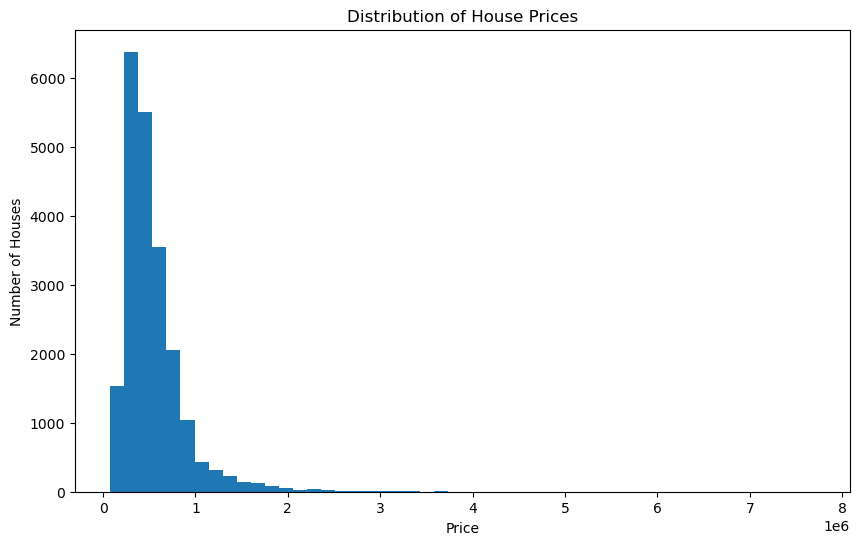

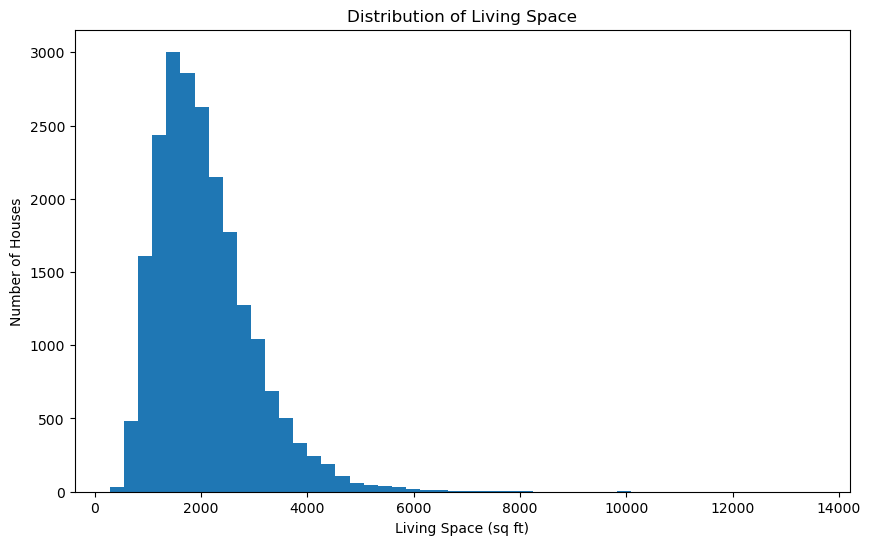

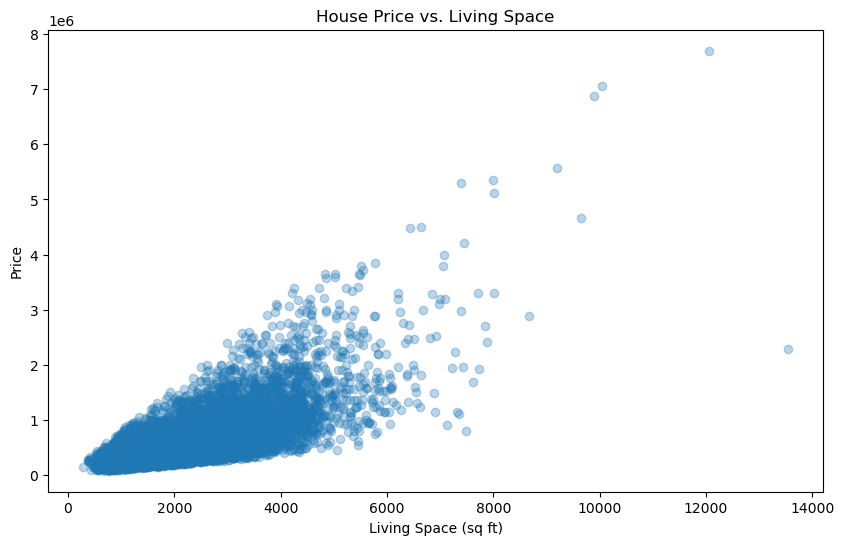

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["price"], bins=50)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

plt.figure(figsize=(10, 6))

plt.hist(df["sqft_living"], bins=50)

plt.title("Distribution of Living Space")
plt.xlabel("Living Space (sq ft)")
plt.ylabel("Number of Houses")

plt.show()

## 10. Relationship Between Living Space and Price 
## We will examine whether houses with more living space tend to have
## higher prices.
plt.figure(figsize=(10, 6))

plt.scatter(
    df["sqft_living"],
    df["price"],
    alpha=0.3
)

plt.title("House Price vs. Living Space")
plt.xlabel("Living Space (sq ft)")
plt.ylabel("Price")

plt.show()